In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
import os
print(os.getcwd())

c:\Users\USER\Desktop\Netflix_Content_Analysis\notebook


In [4]:
print(os.listdir("../dataset"))

['netflix_cleaned.csv', 'netflix_feature_engineered.csv', 'netflix_titles.csv.csv']


In [5]:
df = pd.read_csv("../dataset/netflix_cleaned.csv")

df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International Tv Shows, Tv Dramas, Tv Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,"September 24, 2021",2021,TV-MA,1 Season,"Crime Tv Shows, International Tv Shows, Tv Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality Tv","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International Tv Shows, Romantic Tv Shows, Tv ...",In a city of coaching centers known to train I...


1.Netflix Content Growth Over Time


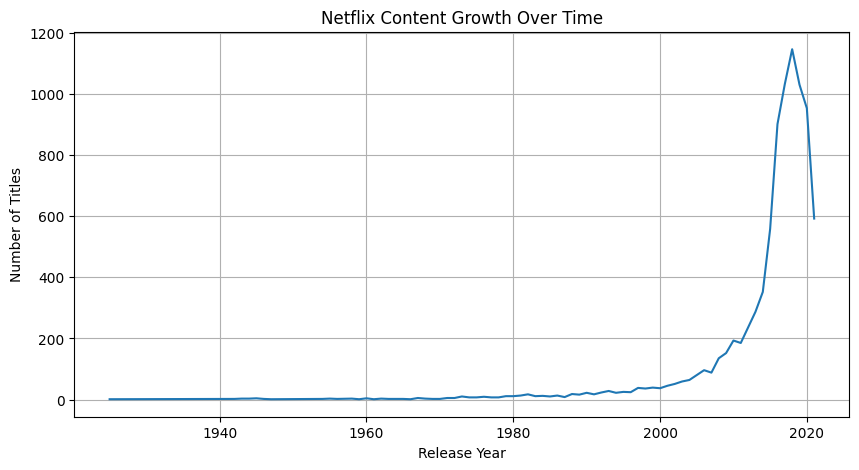

In [6]:

# Count titles per year
yearly_content = df['release_year'].value_counts().sort_index()

# Create graph
plt.figure(figsize=(10, 5))
plt.plot(
    yearly_content.index,
    yearly_content.values,

)

plt.title("Netflix Content Growth Over Time")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")
plt.grid('True')


plt.show()

In [7]:
content_type = df['type'].value_counts()
content_type

type
Movie      6131
TV Show    2666
Name: count, dtype: int64

2.Movies VS TV Shows On Netflix

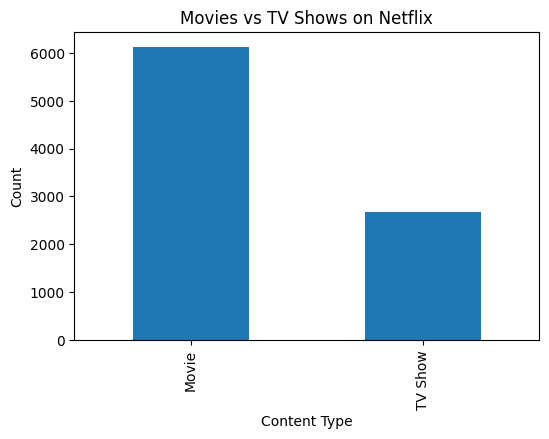

In [8]:


content_type = df['type'].value_counts()

plt.figure(figsize=(6,4))
content_type.plot(kind='bar')

plt.title("Movies vs TV Shows on Netflix")
plt.xlabel("Content Type")
plt.ylabel("Count")
plt.show()

3.Top Most Genres On Netflix

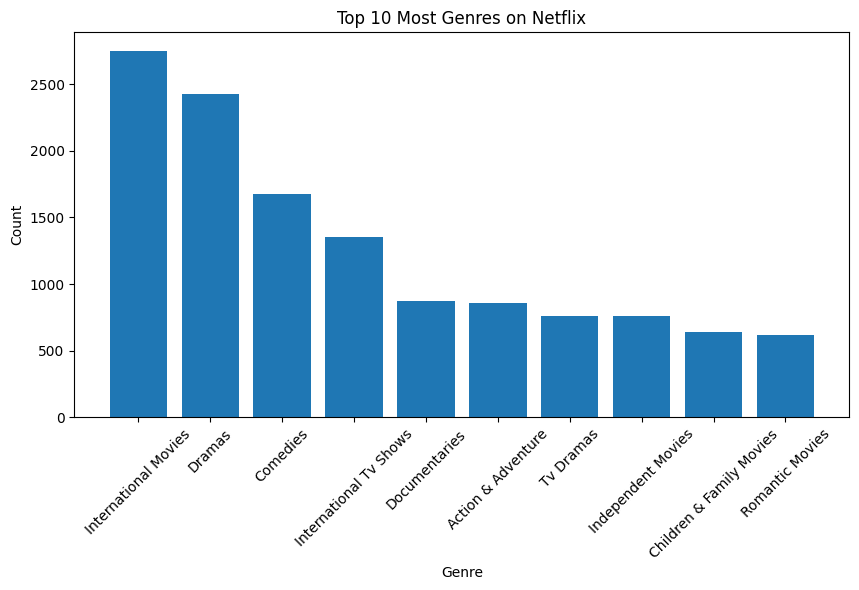

In [9]:
from collections import Counter

genre_counter = Counter()

for genres in df['listed_in']:
    for genre in genres.split(','):
        genre_counter[genre.strip()] += 1

genre_df = pd.DataFrame(
    genre_counter.items(),
   columns=['Genre', 'Count']
)

genre_df = genre_df.sort_values(
    by='Count',
    ascending=False
)

top10_genres = genre_df.head(10)

plt.figure(figsize=(10,5))

plt.bar(
    top10_genres['Genre'],
    top10_genres['Count']
    
)

plt.title("Top 10 Most Genres on Netflix")
plt.xlabel("Genre")
plt.ylabel("Count")

plt.xticks(rotation=45)
plt.show()

4.Least Genres On Netflix

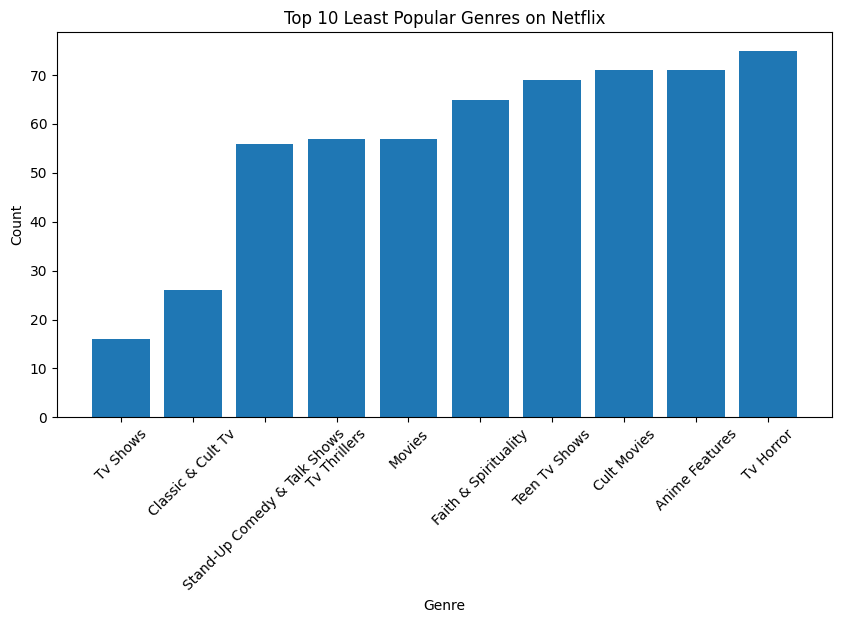

In [10]:
least_genres = genre_df.sort_values(
    by='Count',
    ascending=True
).head(10)

plt.figure(figsize=(10,5))

plt.bar(
    least_genres['Genre'],
    least_genres['Count']
)

plt.title("Top 10 Least Popular Genres on Netflix")
plt.xlabel("Genre")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

In [11]:
#Analyze Ratings


# Count ratings
rating_counts = df['rating'].value_counts()

# Display table
rating_counts

rating
TV-MA       3209
TV-14       2157
TV-PG        861
R            799
PG-13        490
TV-Y7        333
TV-Y         306
PG           287
TV-G         220
NR            79
G             41
TV-Y7-FV       6
NC-17          3
UR             3
74 MIN         1
84 MIN         1
66 MIN         1
Name: count, dtype: int64

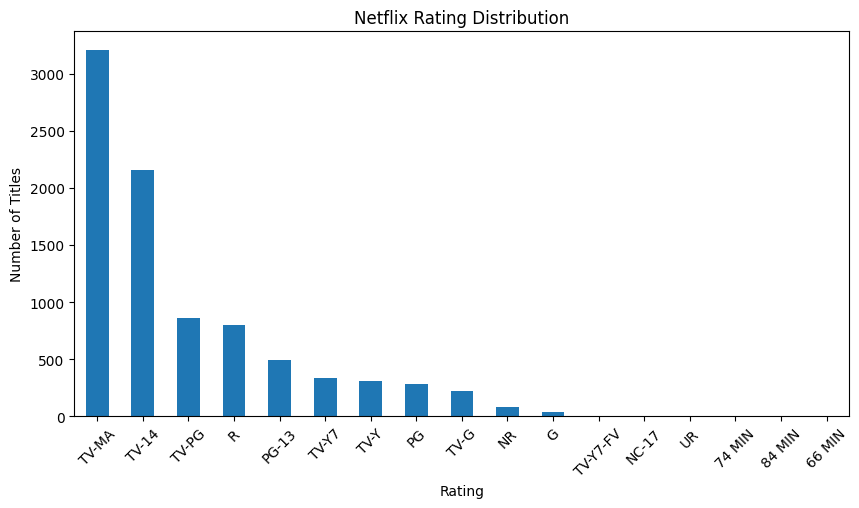

In [12]:
#Rating Distribution Chart

plt.figure(figsize=(10,5))

rating_counts.plot(
    kind='bar'
)

plt.title("Netflix Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of Titles")

plt.xticks(rotation=45)

plt.show()

In [13]:
#To find the most common Rating 

print("Most Common Rating:")
print(rating_counts.idxmax())

print("Count:")
print(rating_counts.max())

Most Common Rating:
TV-MA
Count:
3209


In [14]:
 
# Count titles by country
top_countries = df['country'].value_counts().head(10)

# Display top countries table
top_countries

country
United States     2812
India              972
Unknown            830
United Kingdom     418
Japan              244
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Name: count, dtype: int64

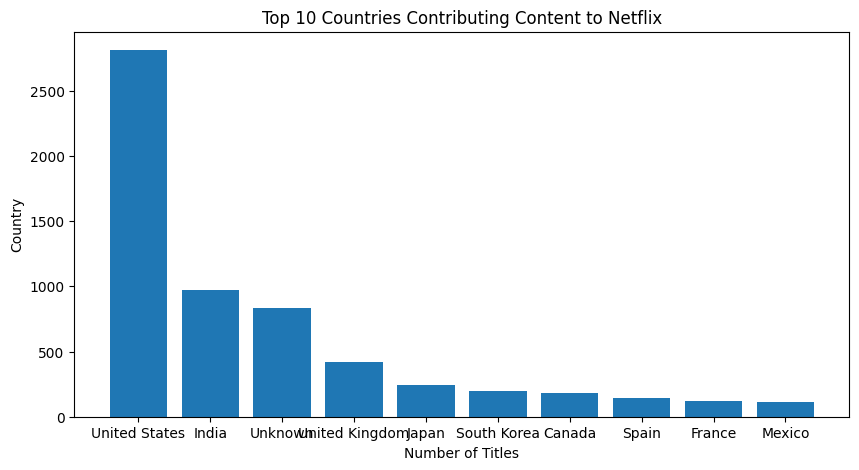

In [15]:


plt.figure(figsize=(10,5))

plt.bar(
    top_countries.index,
    top_countries.values
)

plt.title("Top 10 Countries Contributing Content to Netflix")
plt.xlabel("Number of Titles")
plt.ylabel("Country")

plt.show()

In [16]:
print("Top Country:", top_countries.idxmax())
print("Titles:", top_countries.max())

Top Country: United States
Titles: 2812


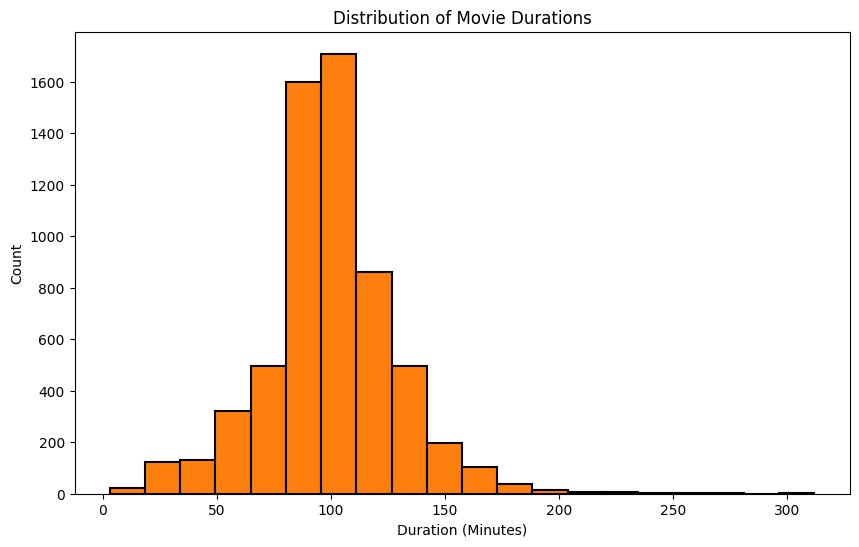

In [27]:
movies = df[df['type'] == 'Movie'].copy()

movies['duration_numeric'] = (
    movies['duration']
    .str.extract('(\\d+)')
    .astype(float)
)

plt.figure(figsize=(10,6))
plt.hist(movies['duration_numeric'], bins=20)

plt.title('Distribution of Movie Durations')
plt.xlabel('Duration (Minutes)')
plt.ylabel('Count')
plt.hist(
    movies['duration_numeric'],
    bins=20,
    edgecolor='black',
    linewidth=1.5
)
plt.show()

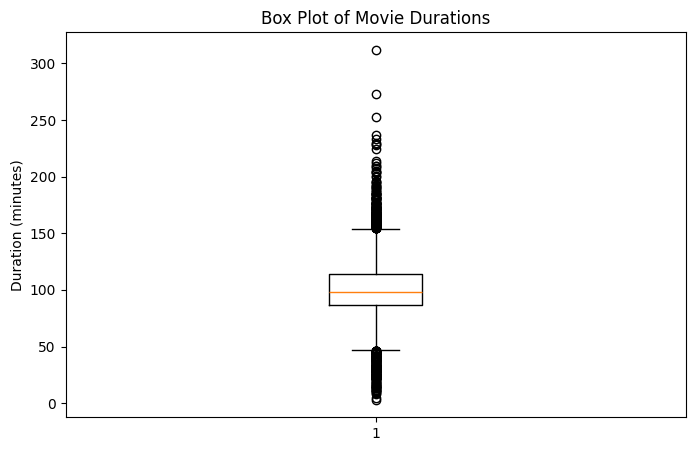

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.boxplot(movies['duration_numeric'].dropna())

plt.title('Box Plot of Movie Durations')
plt.ylabel('Duration (minutes)')
plt.show()

Create Content Length Category

In [41]:
# Create numeric duration column
movies['duration_numeric'] = (
    movies['duration']
    .str.extract(r'(\d+)')
    .astype(float)
)

# Create Content Length Category
def categorize_duration(x):
    if x < 60:
        return 'Short'
    elif x <= 120:
        return 'Medium'
    else:
        return 'Long'

movies['content_length_category'] = movies['duration_numeric'].apply(categorize_duration)

# Check results
print(movies[['duration', 'content_length_category']].head())

   duration content_length_category
0    90 min                  Medium
6    91 min                  Medium
7   125 min                    Long
9   104 min                  Medium
12  127 min                    Long


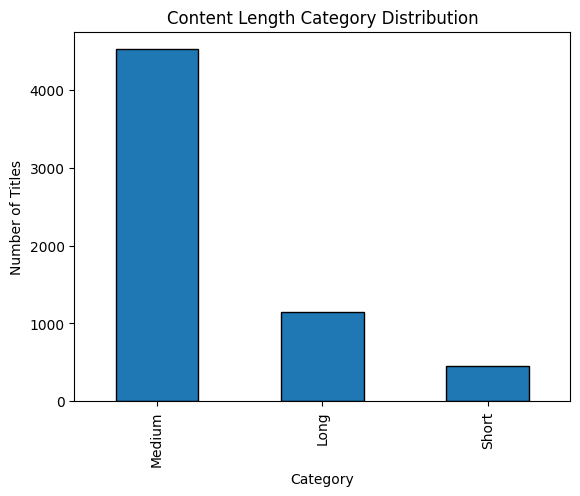

In [42]:
movies['content_length_category'].value_counts().plot(
    kind='bar',
    edgecolor='black'
)

plt.title('Content Length Category Distribution')
plt.xlabel('Category')
plt.ylabel('Number of Titles')
plt.show()

 Create Content Age

In [43]:
# Create Content Age
movies['content_age'] = 2026 - movies['release_year']

# Check results
print(movies[['title', 'release_year', 'content_age']].head())

                               title  release_year  content_age
0               Dick Johnson Is Dead          2020            6
6   My Little Pony: A New Generation          2021            5
7                            Sankofa          1993           33
9                       The Starling          2021            5
12                      Je Suis Karl          2021            5


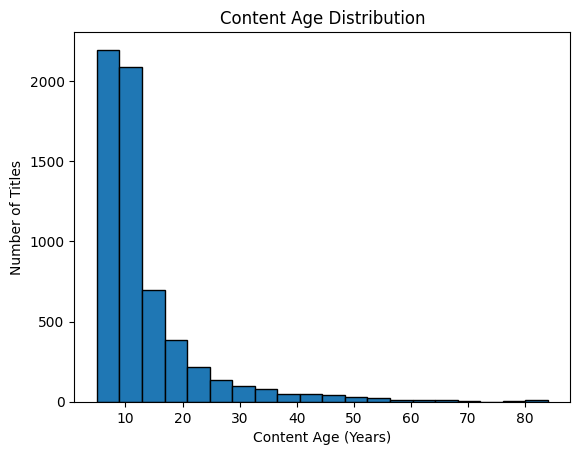

In [44]:
movies['content_age'].plot(
    kind='hist',
    bins=20,
    edgecolor='black'
)

plt.title('Content Age Distribution')
plt.xlabel('Content Age (Years)')
plt.ylabel('Number of Titles')
plt.show()

Create Decade Feature

In [45]:
# Create Decade Feature
movies['decade'] = (movies['release_year'] // 10 * 10).astype(str) + 's'

# Check results
print(movies[['release_year', 'decade']].head())

    release_year decade
0           2020  2020s
6           2021  2020s
7           1993  1990s
9           2021  2020s
12          2021  2020s


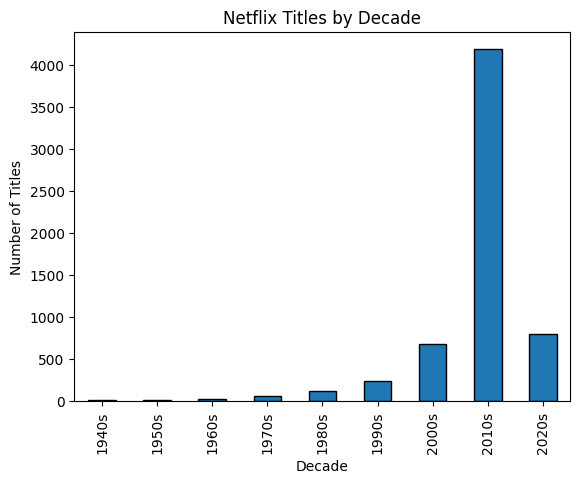

In [46]:
movies['decade'].value_counts().sort_index().plot(
    kind='bar',
    edgecolor='black'
)

plt.title('Netflix Titles by Decade')
plt.xlabel('Decade')
plt.ylabel('Number of Titles')
plt.show()

Create Genre Count

In [49]:
# Create Genre Count
movies['genre_count'] = movies['listed_in'].str.split(',').str.len()

# Check results
print(movies[['title', 'listed_in', 'genre_count']].head())


                               title  \
0               Dick Johnson Is Dead   
6   My Little Pony: A New Generation   
7                            Sankofa   
9                       The Starling   
12                      Je Suis Karl   

                                           listed_in  genre_count  
0                                      Documentaries            1  
6                           Children & Family Movies            1  
7   Dramas, Independent Movies, International Movies            3  
9                                   Comedies, Dramas            2  
12                      Dramas, International Movies            2  


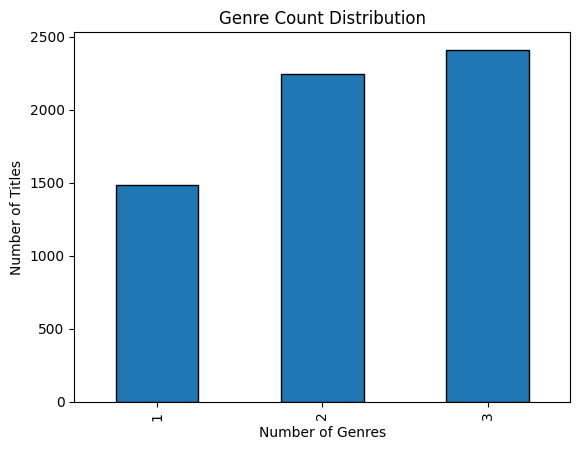

In [50]:
movies['genre_count'].value_counts().sort_index().plot(
    kind='bar',
    edgecolor='black'
)

plt.title('Genre Count Distribution')
plt.xlabel('Number of Genres')
plt.ylabel('Number of Titles')
plt.show()

In [51]:
# Select engineered features
feature_dataset = movies[
    ['content_length_category', 'content_age', 'decade', 'genre_count']
]

# Save to CSV
feature_dataset.to_csv('netflix_featured.csv', index=False)

print("netflix_featured.csv created successfully!")
print(feature_dataset.head())

netflix_featured.csv created successfully!
   content_length_category  content_age decade  genre_count
0                   Medium            6  2020s            1
6                   Medium            5  2020s            1
7                     Long           33  1990s            3
9                   Medium            5  2020s            2
12                    Long            5  2020s            2


In [52]:
print(feature_dataset.info())

<class 'pandas.DataFrame'>
Index: 6131 entries, 0 to 8796
Data columns (total 4 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   content_length_category  6131 non-null   str  
 1   content_age              6131 non-null   int64
 2   decade                   6131 non-null   str  
 3   genre_count              6131 non-null   int64
dtypes: int64(2), str(2)
memory usage: 239.5 KB
None
